In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
X_train = pd.read_csv("shuffled_train_final_x.csv")
X_test = pd.read_csv("shuffled_test_final_x.csv")
X_val = pd.read_csv("shuffled_val_final_x.csv")

y_train = pd.read_csv("shuffled_train_final_y.csv")
y_test = pd.read_csv("shuffled_test_final_y.csv")
y_val = pd.read_csv("shuffled_val_final_y.csv")

In [4]:
#There are som NaNs in our dataset in age, since some images didn't hae the age metadata
row_indices, col_indices = np.where(np.isnan(X_train))
# print(np.shape(row_indices))
age_sum = X_train["age"].sum()
num_ppl = X_train["age"].count()
average_age = int(age_sum / num_ppl)
# fill na
X_train = X_train.fillna(average_age)

In [32]:
#FOR X_TEST
#There are som NaNs in our dataset in age, since some images didn't hae the age metadata
row_indices, col_indices = np.where(np.isnan(X_test))
# print(np.shape(row_indices))
age_sum = X_test["age"].sum()
num_ppl = X_test["age"].count()
average_age = int(age_sum / num_ppl)
# fill na
X_test = X_test.fillna(average_age)

In [33]:
#FOR X_AL
#There are som NaNs in our dataset in age, since some images didn't hae the age metadata
row_indices, col_indices = np.where(np.isnan(X_val))
# print(np.shape(row_indices))
age_sum = X_val["age"].sum()
num_ppl = X_val["age"].count()
average_age = int(age_sum / num_ppl)
# fill na
X_val = X_val.fillna(average_age)

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [ ]:
pca = PCA(n_components=7010) #n_components is Number of components to keep. we have 7010 observations, let's keep all of them
"""
NOTE: for n_components, 
In essence, while you might have many features, 
the actual information content and variability in your data are
 ultimately constrained by the number of observations you have. 
 You cannot extract more independent directions of variance than 
 the number of independent samples available to define those 
 directions.
"""
pca_result = pca.fit_transform(X_scaled)

In [21]:
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

cumulative_variance = np.cumsum(explained_variance)
print("Cumulative Explained Variance:", cumulative_variance)

print("Shape of transformed data:", pca_result.shape)

[3.41988866e-01 1.86827080e-01 1.24692614e-01 ... 2.64211282e-08
 1.17716687e-33 1.90233064e-34]
Cumulative Explained Variance: [0.34198887 0.52881595 0.65350856 ... 1.         1.         1.        ]
Shape of transformed data: (7010, 7010)


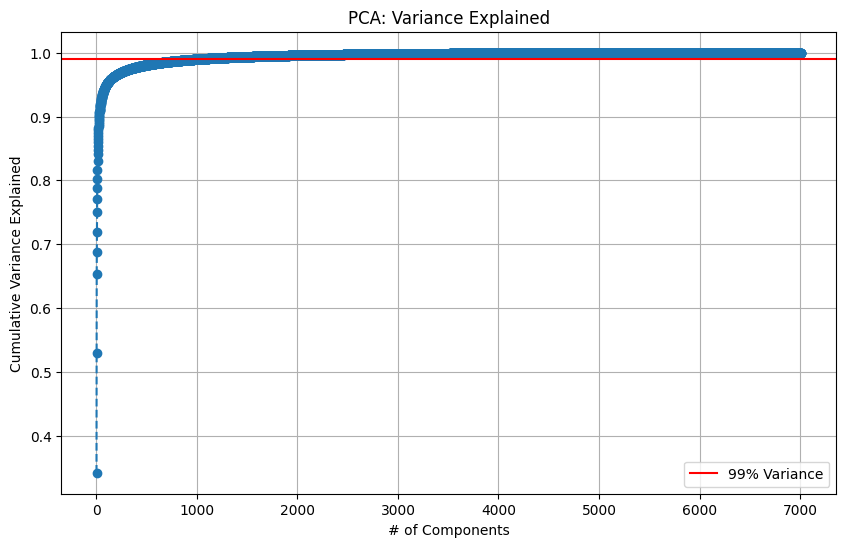

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('PCA: Variance Explained')
plt.xlabel('# of Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.axhline(y=0.99, color='r', linestyle='-', label='99% Variance') # threshold line
plt.legend()
plt.show()

In [24]:
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1
print("components needed to explain at least 95% variance: ", (n_components_99))

components needed to explain at least 95% variance:  1020


In [ ]:
pca_99 = PCA(n_components=n_components_99)
X_pca_train = pca_99.fit_transform(X_train)
print("Shape of transformed data:", X_pca_train.shape)

Shape of transformed data: (7010, 1020)


In [34]:
#Now we need to do PCA on all of the other X  (feature) sets
X_pca_test = pca_99.fit_transform(X_test)
print("Shape of transformed data:", X_pca_test.shape)

X_pca_val = pca_99.fit_transform(X_val)
print("Shape of transformed data:", X_pca_val.shape)

Shape of transformed data: (1503, 1020)
Shape of transformed data: (1502, 1020)


In [ ]:
#Exporting X_train
X_pca_train_df = pd.DataFrame(X_pca_train)
X_pca_train_df.to_csv('X_train_pca.csv', index=False)

In [35]:
#Exporting X_test
X_pca_test_df = pd.DataFrame(X_pca_test)
X_pca_test_df.to_csv('X_test_pca.csv', index=False)

In [36]:
#Exporting X_val
X_pca_val_df = pd.DataFrame(X_pca_val)
X_pca_val_df.to_csv('X_val_pca.csv', index=False)